<a href="https://colab.research.google.com/github/PrayashRM/CNN-dog-cat-classifier/blob/main/Project04_Animal_Faces_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Dependencies**

In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device avaliable: " , device)

Mounted at /content/drive
Device avaliable:  cpu


# **Loading the Dataset**

In [ ]:
!pip install opendatasets --quiet

prayashranjanmohanty

17dd85a11c6d9444328e0858351f74a6

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: prayashranjanmohanty
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 96.3MB/s]


In [ ]:
images_path = []
label = []

base_path = "/content/animal-faces/afhq"

for class_name in os.listdir("/content/animal-faces/afhq"):
  for label_class in os.listdir(f"/content/animal-faces/afhq/{class_name}"):
    for image_path in os.listdir(f"/content/animal-faces/afhq/{class_name}/{label_class}"):
      images_path.append(f"/content/animal-faces/afhq/{class_name}/{label_class}/{image_path}")
      label.append(label_class)

data = pd.DataFrame({"images":images_path , "label":label})


In [ ]:
data.head()

,images,label
0,/content/animal-faces/afhq/val/wild/pixabay_wi...,wild
1,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
2,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
3,/content/animal-faces/afhq/val/wild/flickr_wil...,wild
4,/content/animal-faces/afhq/val/wild/flickr_wil...,wild


In [ ]:
data.shape

(16130, 2)

In [ ]:
data.isnull().sum()

,0
images,0
label,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.label.value_counts()

,count
label,
cat,5653
dog,5239
wild,5238


No Redundant columns ,
No Null values ,
No Deuplicated values

In [ ]:
data.columns

Index(['images', 'label'], dtype='object')

In [ ]:
#Categorizing data

data['label'] = data['label'].map({
    "wild" : 0,
    "dog" : 1,
    "cat" : 2
    })

In [ ]:
data['label'].isnull().sum()

np.int64(0)

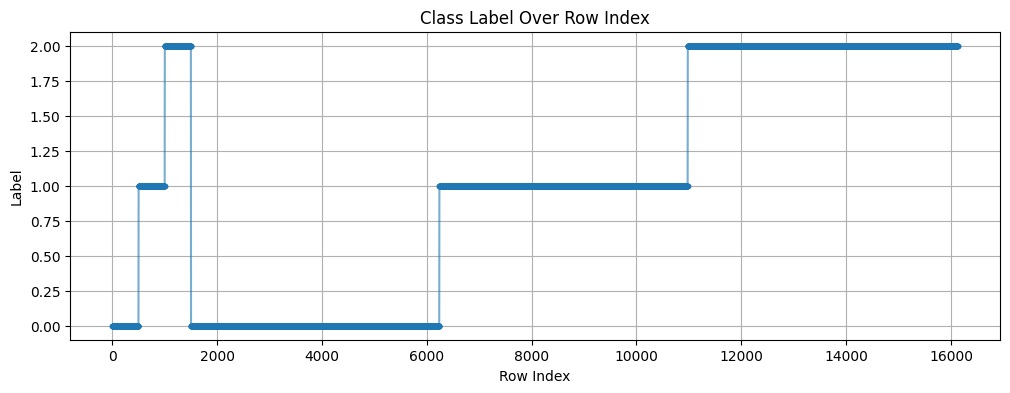

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(data['label'], marker='.', linestyle='-', alpha=0.6)
plt.title("Class Label Over Row Index")
plt.xlabel("Row Index")
plt.ylabel("Label")
plt.grid(True)
plt.show()


# **Split data**

In [ ]:
train = data.sample(frac=0.7, random_state=0)
test = data.drop(train.index)

val = test.sample(frac=0.5, random_state=0)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [ ]:
#this is split via train_test_split, but already the code is strucutred for data.sample output split, so didn't change to train_test_split



#X = data['images']
#Y = data['label']

#x_train , x_test , y_train , y_test = train_test_split( X , Y ,
#                                                      test_size = 0.3,
#                                                      random_state=46,
#                                                       shuffle=True,
#                                                       stratify = Y)
#
##x_val , x_test , y_val , y_test = train_test_split( x_test , y_test ,
#                                                      test_size = 0.5,
#                                                      random_state=46,
#                                                       shuffle=True,
#                                                       stratify = y_test)

# **Data Augmentation**

In [ ]:
transform = transforms.Compose([

    #Always apply
    transforms.Resize((128 , 128)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

# **Dataset & DataLoader**

In [ ]:
class customdataset(Dataset):

  def __init__(self , data , transform = None):
    self.data = data
    self.transform = transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    image_pth = self.data.iloc[index , 0]
    label = self.data.iloc[index , 1]

    image = Image.open(image_pth) #Opens the image , as transforms can't work on image path
    image = image.convert("RGB") #Ensures that the images are in RGB only (else mid training could get size mismatch errors)

    if self.transform is not None:
      image = self.transform(image)

    label = torch.tensor(label).long()
    return image , label


In [ ]:
train_dataset = customdataset( data = train , transform = transform)
test_dataset = customdataset( data = test , transform = transform)
val_dataset = customdataset( data = val , transform = transform)

In [ ]:
#creating DataLoaders

train_loader = DataLoader(train_dataset , batch_size=128 , shuffle=True , num_workers=2 , pin_memory=True)
test_loader = DataLoader(test_dataset , batch_size=128 , shuffle=False ,num_workers=2 , pin_memory=True)
val_loader = DataLoader(val_dataset , batch_size=128 , shuffle=False ,num_workers=2 , pin_memory=True)

In [ ]:
print(len(val_dataset))

2420


# **CNN Architecture**

In [ ]:
class MyCNNmodelNet(nn.Module):

  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32 , kernel_size = 3 , padding = 1)
    self.conv2 = nn.Conv2d(32, 64 , kernel_size = 3 , padding = 1)
    self.conv3 = nn.Conv2d(64, 128 , kernel_size = 3 , padding = 1)

    self.pooling = nn.MaxPool2d(2 , 2)
    self.relu = nn.ReLU()

    self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
    self.flatten = nn.Flatten()

    self.linear = nn.Linear(128, 128)
    self.output = nn.Linear(128 , len(data['label'].unique()))

  def forward(self , x):

    x = self.conv1(x)
    x = self.relu(x)
    x = self.pooling(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.pooling(x)

    x = self.conv3(x)
    x = self.relu(x)
    x = self.pooling(x)

    x = self.global_pool(x)
    x = self.flatten(x)
    x = self.linear(x)
    x = self.relu(x)
    x = self.output(x)
    return x


In [ ]:
model = MyCNNmodelNet()
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
summary( model, input_size= (3 , 128 , 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
AdaptiveAvgPool2d-10            [-1, 128, 1, 1]               0
          Flatten-11                  [-1, 128]               0
           Linear-12                  [-1, 128]          16,512
             ReLU-13                  [-1, 128]               0
           Linear-14                   

# **Training Loop**

In [ ]:
import torch

# Check if GPU is available
print("CUDA Available:", torch.cuda.is_available())

# Check device name
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


CUDA Available: True
GPU Name: Tesla T4


In [ ]:
lr = 0.005

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters() , lr = lr)

In [ ]:
model = MyCNNmodelNet()
model.to(device)

losses = []
epoch = []
val = []

epochs = 2000

best_val_loss = float('inf')
patience = 15
wait = 0

for i in range(epochs):

    model.train()

    total_epoch_loss = 0

    for x_batch , y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        #forward pass
        prediction = model(x_batch)

        #loss calculation
        loss = criterion(prediction , y_batch)
        total_epoch_loss += loss.item()

        #gradient calculation
        optimizer.zero_grad()
        loss.backward()

        #gradient update
        optimizer.step()

    avg_training_loss = total_epoch_loss/(len(train_loader))
    print('Epoch: ' , i + 1 , ' , avg loss: ' , avg_training_loss)
    losses.append(avg_training_loss)
    epoch.append(i + 1)

    #Validation set
    model.eval()
    total_loss = 0.0
    with torch.no_grad():

        for x_batch , y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            #forward pass
            prediction = model(x_batch)

            #Loss calculation
            loss = criterion(prediction , y_batch)
            total_loss += loss.item()

        avg_validation_loss = total_loss / (len(val_loader))
        val.append(avg_validation_loss)

    #early stopping
    if avg_validation_loss < best_val_loss:
        best_val_loss = avg_validation_loss
        wait = 0

        current_model_path = "/content/drive/MyDrive/COLAB/Project04/Saved_Models/Project04_Animal_faces_currentmodel.pth"
        torch.save(model.state_dict(), current_model_path) # Save the best model

    else:
        wait += 1
        if wait >= patience:
            print(f"⛔ Early stopping at epoch {i + 1}")
            break




plt.figure(figsize=(10, 5))
plt.plot(epoch, losses, marker='o', linestyle='-', color='blue', linewidth=2, label='Train Loss')
plt.plot(epoch, val, marker='x', linestyle='--', color='orange', linewidth=2, label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# **Evaluation**

In [ ]:
model.eval()

correct = 0
total = 0
total_epoch_loss = 0.0

with torch.no_grad():

    for x_batch , y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        #forward pass
        prediction = model(x_batch)

        #loss calculation
        loss = criterion(prediction , y_batch)
        total_epoch_loss += loss.item()

        #accuracy calculation
        predicted_class = torch.argmax(prediction, dim=1)
        correct += (predicted_class == y_batch).sum().item()
        total += y_batch.size(0)

    avg_loss = total_epoch_loss / (len(test_loader))
    print(f'Avg Loss is: {avg_loss}')

    accuracy = (correct / total) * 100
    print(f'Accuracy: {accuracy} %')

Avg Loss is: 0.09279578561453443
Accuracy: 96.77552707730467 %


# **Model saving and loading**

In [ ]:
best_model_path = "/content/drive/MyDrive/COLAB/Project04/Saved_Models/Project04_Animal_faces_Bestmodel_Full_transform.pth"

current_model_path = "/content/drive/MyDrive/COLAB/Project04/Saved_Models/Project04_Animal_faces_currentmodel.pth"

In [ ]:
torch.save(model.state_dict(), best_model_path) #use best_model_path (if want to use the best model saved till now) or current_model_path (if want to use the autosaved best model till now)

In [ ]:
model = MyCNNmodelNet()
model.load_state_dict(torch.load(best_model_path))  #use best_model_path (if want to use the best model saved till now) or current_model_path (if want to use the autosaved best model till now)
model.to(device)
model.eval()

MyCNNmodelNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=128, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=3, bias=True)
)

# **Self Testing**

In [ ]:
#First load the required model

#Only apply the necessary required transformations to input the image into the model
transform = transforms.Compose([
    #Always apply
    transforms.Resize((128 , 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

#Establish the Image path & apply transformations
base_img_path = "/content/drive/MyDrive/COLAB/Project04/test_images"
image_name = "download.jpg"
img_path = os.path.join(base_img_path , image_name)
image = Image.open(img_path).convert("RGB")
image = transform(image)

#Bring the image to the same dimension
image = image.unsqueeze(0).to(device) # Have to add one more dimension of batch , as this is a single image in the correct shape , but the expected input is as (batch) 4D , where the batch dimension is the 4th dimension

#Input the image to the loaded model and make prediction
with torch.no_grad():
    output = model(image)
    predicted_class = torch.argmax(output, dim=1).item()

label_map = {0: 'wild', 1: 'dog', 2: 'cat'}   #converting the numeric label to the corresponding label name
print(f"Predicted label: {label_map[predicted_class]}")

Predicted label: cat
